## Gisma University of Applied Sciences
### Department of Computer Science

## A Reliability-Aware Machine Learning Framework for Sentiment Classification of Social Media Posts
### Name: Yatin (GH1035214)



In [40]:
# 0. INSTALL / IMPORT LIBRARIES

import os
import re
import gc
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")


RANDOM_STATE = 42

TEST_SIZE = 0.20

CV_FOLDS = 5

FILE_PATH = "tweet.csv"
DEVELOPMENT_MODE = False
DEVELOPMENT_SAMPLE_SIZE = 300000
OUTPUT_DIR = "RASCA_results"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)




In [41]:
# 1. LOAD DATASET

print("\n" + "=" * 80)
print("[1] LOADING DATASET")
print("=" * 80)


if not os.path.exists(FILE_PATH):

    raise FileNotFoundError(
        f"""
Dataset not found: {FILE_PATH}

Please place the Sentiment140 CSV file in the
Jupyter working directory or change FILE_PATH.
"""
    )

raw_preview = pd.read_csv(
    FILE_PATH,
    header=None,
    encoding="latin-1",
    nrows=5
)
print("\nFirst five raw rows:")
display(raw_preview)


print("\nRaw preview shape:")

print(raw_preview.shape)


print("\nLoading complete dataset...")


df = pd.read_csv(
    FILE_PATH,
    header=None,
    encoding="latin-1",
    names=[
        "target",
        "ids",
        "date",
        "flag",
        "user",
        "text"
    ]
)


print(f"\nRows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


print("\nColumn names:")

print(df.columns.tolist())




[1] LOADING DATASET

First five raw rows:


,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."



Raw preview shape:
(5, 6)

Loading complete dataset...

Rows:    1,600,000
Columns: 6

Column names:
['target', 'ids', 'date', 'flag', 'user', 'text']


In [42]:
# 2. DATASET VERIFICATION

print("\n" + "=" * 80)
print("[2] DATASET VERIFICATION")
print("=" * 80)
print("\nData types:")
display(df.dtypes.to_frame("Data_Type"))
print("\nMissing values:")


missing_table = pd.DataFrame({
    "Missing_Count":
        df.isnull().sum(),

    "Missing_Percentage":
        df.isnull().mean() * 100
})
display(missing_table)
missing_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "00_missing_value_analysis.csv"
    )
)

print("\nDuplicate rows:")
duplicate_count = df.duplicated().sum()
print(
    f"Duplicate rows: {duplicate_count:,}"
)
print("\nUnique values per column:")
unique_table = pd.DataFrame({

    "Column":
        df.columns,

    "Unique_Values":
        [
            df[column].nunique(
                dropna=False
            )
            for column in df.columns
        ]
})
display(unique_table)
unique_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "00_unique_values_analysis.csv"
    ),
    index=False
)

print("\nFirst five correctly interpreted records:")
display(df.head())
memory_gb = (
    df.memory_usage(deep=True).sum()
    /
    (1024 ** 3)
)


print(
    f"\nDataset memory usage: {memory_gb:.2f} GB"
)



[2] DATASET VERIFICATION

Data types:


,Data_Type
target,int64
ids,int64
date,str
flag,str
user,str
text,str



Missing values:


,Missing_Count,Missing_Percentage
target,0,0.0
ids,0,0.0
date,0,0.0
flag,0,0.0
user,0,0.0
text,0,0.0



Duplicate rows:
Duplicate rows: 0

Unique values per column:


,Column,Unique_Values
0,target,2
1,ids,1598315
2,date,774363
3,flag,1
4,user,659775
5,text,1581466



First five correctly interpreted records:


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."



Dataset memory usage: 0.25 GB


In [43]:
# 3. VERIFY TARGET LABELS

print("\n" + "=" * 80)
print("[3] TARGET LABEL VERIFICATION")
print("=" * 80)


target_counts = (
    df["target"]
    .value_counts(dropna=False)
    .sort_index()
)


print("\nTarget distribution:")

display(
    target_counts.to_frame("Count")
)


target_percentages = (
    df["target"]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .sort_index()
    .mul(100)
    .round(4)
)


print("\nTarget percentages:")

display(
    target_percentages.to_frame(
        "Percentage"
    )
)


unique_targets = sorted(
    pd.to_numeric(
        df["target"],
        errors="coerce"
    )
    .dropna()
    .unique()
)


print("\nUnique numeric target labels:")

print(unique_targets)


if not set(unique_targets).issubset({0, 2, 4}):

    print(
        "\nWARNING:"
        "\nUnexpected target labels detected."
        "\nThe dataset will not be silently modified."
    )


if 0 not in unique_targets or 4 not in unique_targets:

    raise ValueError(
        "Expected Sentiment140 labels 0 and 4 "
        "were not both found."
    )




[3] TARGET LABEL VERIFICATION

Target distribution:


,Count
target,
0,800000
4,800000



Target percentages:


,Percentage
target,
0,50.0
4,50.0



Unique numeric target labels:
[np.int64(0), np.int64(4)]


In [44]:
# 4. CREATE BINARY DATASET

print("\n" + "=" * 80)
print("[4] BINARY SENTIMENT DATASET")
print("=" * 80)
binary_df = df[
    df["target"].isin([0, 4])
].copy()


print(
    f"Original records: {len(df):,}"
)

print(
    f"Binary records:   {len(binary_df):,}"
)

print(
    f"Excluded records: "
    f"{len(df) - len(binary_df):,}"
)



binary_df["sentiment"] = (
    binary_df["target"]
    .map({
        0: 0,
        4: 1
    })
    .astype("int8")
)


print("\nBinary label distribution:")


binary_counts = (
    binary_df["sentiment"]
    .value_counts()
    .sort_index()
)


binary_table = pd.DataFrame({

    "Label":
        ["Negative", "Positive"],

    "Numeric_Label":
        [0, 1],

    "Count":
        [
            binary_counts.get(0, 0),
            binary_counts.get(1, 0)
        ]
})


binary_table["Percentage"] = (
    binary_table["Count"]
    /
    binary_table["Count"].sum()
    *
    100
).round(4)


display(binary_table)


binary_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "01_binary_class_distribution.csv"
    ),
    index=False
)




[4] BINARY SENTIMENT DATASET
Original records: 1,600,000
Binary records:   1,600,000
Excluded records: 0

Binary label distribution:


,Label,Numeric_Label,Count,Percentage
0,Negative,0,800000,50.0
1,Positive,1,800000,50.0


In [45]:
# 5. REMOVE INVALID TEXT RECORDS

print("\n" + "=" * 80)
print("[5] TEXT QUALITY CHECK")
print("=" * 80)


binary_df["text"] = (
    binary_df["text"]
    .fillna("")
    .astype(str)
)


empty_text_count = (
    binary_df["text"]
    .str.strip()
    .eq("")
    .sum()
)


print(
    f"Empty text records: "
    f"{empty_text_count:,}"
)


binary_df = binary_df[
    binary_df["text"]
    .str.strip()
    .ne("")
].copy()


print(
    f"Records after text validation: "
    f"{len(binary_df):,}"
)




[5] TEXT QUALITY CHECK
Empty text records: 0
Records after text validation: 1,600,000


In [46]:
# 6. OPTIONAL DEVELOPMENT SAMPLE

print("\n" + "=" * 80)
print("[6] DATASET MODE")
print("=" * 80)


if DEVELOPMENT_MODE:

    print(
        f"Using stratified development sample "
        f"of {DEVELOPMENT_SAMPLE_SIZE:,} records."
    )


    if DEVELOPMENT_SAMPLE_SIZE >= len(binary_df):

        print(
            "Development sample size is larger "
            "than the available dataset."
        )

    else:

        binary_df, _ = train_test_split(

            binary_df,

            test_size=(
                len(binary_df)
                -
                DEVELOPMENT_SAMPLE_SIZE
            ),

            stratify=binary_df["sentiment"],

            random_state=RANDOM_STATE
        )


        binary_df = (
            binary_df
            .reset_index(drop=True)
        )


    print(
        f"Development records: "
        f"{len(binary_df):,}"
    )


else:

    print(
        "FULL DATASET MODE"
    )

    print(
        f"Using all valid binary records: "
        f"{len(binary_df):,}"
    )




[6] DATASET MODE
FULL DATASET MODE
Using all valid binary records: 1,600,000


In [47]:
# 7. TEXT PREPROCESSING FUNCTION

print("\n" + "=" * 80)
print("[7] TEXT PREPROCESSING")
print("=" * 80)


def clean_tweet(text):

    """
    Lightweight social-media text preprocessing.

    Operations:
    1. Lowercase
    2. Remove URLs
    3. Remove HTML
    4. Remove @mentions
    5. Remove hashtag symbol but retain hashtag word
    6. Remove most non-alphanumeric noise
    7. Normalize whitespace

    Negation words such as:
        not
        never
        no

    are retained.
    """

    text = str(text)


    # Lowercase

    text = text.lower()


    # Remove URLs

    text = re.sub(
        r"http\S+|www\S+|https\S+",
        " ",
        text
    )


    # Remove HTML

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )


    # Remove user mentions

    text = re.sub(
        r"@\w+",
        " ",
        text
    )


    # Keep hashtag word

    text = re.sub(
        r"#(\w+)",
        r"\1",
        text
    )


    # Remove unwanted characters

    text = re.sub(
        r"[^a-zA-Z0-9'\s]",
        " ",
        text
    )


    # Normalize whitespace

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()


    return text


# ------------------------------------------------
# Apply preprocessing
# ------------------------------------------------

print(
    "Creating cleaned text..."
)


binary_df["clean_text"] = (
    binary_df["text"]
    .map(clean_tweet)
)


print(
    "\nOriginal vs cleaned examples:"
)


example_table = binary_df[
    [
        "text",
        "clean_text",
        "sentiment"
    ]
].head(10)


display(example_table)


example_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "02_preprocessing_examples.csv"
    ),
    index=False
)



[7] TEXT PREPROCESSING
Creating cleaned text...

Original vs cleaned examples:


,text,clean_text,sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",a that's a bummer you shoulda got david carr o...,0
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,0
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...,0
5,@Kwesidei not the whole crew,not the whole crew,0
6,Need a hug,need a hug,0
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...,0
8,@Tatiana_K nope they didn't have it,nope they didn't have it,0
9,@twittera que me muera ?,que me muera,0


In [48]:
# 8. REMOVE TEXT THAT BECAME EMPTY

print("\n" + "=" * 80)
print("[8] FINAL TEXT VALIDATION")
print("=" * 80)


before_empty_removal = len(binary_df)


binary_df = binary_df[
    binary_df["clean_text"]
    .str.strip()
    .ne("")
].copy()


after_empty_removal = len(binary_df)


removed_count = (
    before_empty_removal
    -
    after_empty_removal
)


print(
    f"Removed empty cleaned texts: "
    f"{removed_count:,}"
)


print(
    f"Final modelling records: "
    f"{after_empty_removal:,}"
)



[8] FINAL TEXT VALIDATION
Removed empty cleaned texts: 3,594
Final modelling records: 1,596,406


In [49]:
# 9. TRAIN / TEST SPLIT

print("\n" + "=" * 80)
print("[9] STRATIFIED TRAIN / TEST SPLIT")
print("=" * 80)


X = binary_df["clean_text"]

y = binary_df["sentiment"]


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=TEST_SIZE,

    stratify=y,

    random_state=RANDOM_STATE
)


print(
    f"Training records: "
    f"{len(X_train):,}"
)


print(
    f"Testing records:  "
    f"{len(X_test):,}"
)


print("\nTraining class distribution:")


display(
    y_train
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(3)
    .to_frame(
        "Percentage"
    )
)


print("\nTesting class distribution:")


display(
    y_test
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(3)
    .to_frame(
        "Percentage"
    )
)



[9] STRATIFIED TRAIN / TEST SPLIT
Training records: 1,277,124
Testing records:  319,282

Training class distribution:


,Percentage
sentiment,
0,50.009
1,49.991



Testing class distribution:


,Percentage
sentiment,
0,50.009
1,49.991


In [50]:
# 10. TF-IDF CONFIGURATION

print("\n" + "=" * 80)
print("[10] TF-IDF CONFIGURATION")
print("=" * 80)


tfidf = TfidfVectorizer(

    ngram_range=(1, 2),

    min_df=5,

    max_df=0.95,

    sublinear_tf=True,

    max_features=300000,

    strip_accents="unicode"
)


print("TF-IDF settings:")

print("n-grams: 1-2")

print("min_df: 5")

print("max_df: 0.95")

print("sublinear_tf: True")

print("max_features: 300,000")


print(
    "\nTF-IDF is fitted ONLY on the training data."
)

print(
    "This prevents test-set information leakage."
)


X_train_tfidf = (
    tfidf.fit_transform(X_train)
)




X_test_tfidf = (
    tfidf.transform(X_test)
)


print(
    "\nTraining TF-IDF shape:"
)

print(
    X_train_tfidf.shape
)


print(
    "\nTesting TF-IDF shape:"
)

print(
    X_test_tfidf.shape
)


print(
    f"\nNumber of learned TF-IDF features: "
    f"{len(tfidf.vocabulary_):,}"
)



feature_names = np.array(
    tfidf.get_feature_names_out()
)


pd.DataFrame({
    "feature": feature_names
}).to_csv(

    os.path.join(
        OUTPUT_DIR,
        "03_tfidf_features.csv"
    ),

    index=False
)




[10] TF-IDF CONFIGURATION
TF-IDF settings:
n-grams: 1-2
min_df: 5
max_df: 0.95
sublinear_tf: True
max_features: 300,000

TF-IDF is fitted ONLY on the training data.
This prevents test-set information leakage.

Training TF-IDF shape:
(1277124, 300000)

Testing TF-IDF shape:
(319282, 300000)

Number of learned TF-IDF features: 300,000


In [51]:
# 11. STRATIFIED CROSS-VALIDATION SETUP

print("\n" + "=" * 80)
print("[11] STRATIFIED CROSS-VALIDATION")
print("=" * 80)


skf = StratifiedKFold(

    n_splits=CV_FOLDS,

    shuffle=True,

    random_state=RANDOM_STATE
)


print(
    f"Cross-validation folds: "
    f"{CV_FOLDS}"
)


print(
    "Shuffle: True"
)


print(
    f"Random state: "
    f"{RANDOM_STATE}"
)



[11] STRATIFIED CROSS-VALIDATION
Cross-validation folds: 5
Shuffle: True
Random state: 42


In [52]:
# 12. MODEL DEFINITIONS

print("\n" + "=" * 80)
print("[12] MODEL DEFINITIONS")
print("=" * 80)



models = {

    "Logistic Regression":
        LogisticRegression(

            C=1.0,

            max_iter=1000,

            class_weight="balanced",

            random_state=RANDOM_STATE
        ),


    "Multinomial Naive Bayes":
        MultinomialNB(

            alpha=1.0
        ),


    "Linear SVM":
        LinearSVC(

            C=1.0,

            class_weight="balanced",

            random_state=RANDOM_STATE
        )
}


for model_name in models:

    print(
        "•",
        model_name
    )




[12] MODEL DEFINITIONS
• Logistic Regression
• Multinomial Naive Bayes
• Linear SVM


In [53]:

# 13. MODEL CONFIGURATION

print("\n" + "=" * 80)
print("[13] FIXED MODEL CONFIGURATION")
print("=" * 80)


model_configuration = pd.DataFrame([

    {
        "Model":
            "Logistic Regression",

        "Parameters":
            "C=1.0, class_weight=balanced, max_iter=1000"
    },

    {
        "Model":
            "Multinomial Naive Bayes",

        "Parameters":
            "alpha=1.0"
    },

    {
        "Model":
            "Linear SVM",

        "Parameters":
            "C=1.0, class_weight=balanced"
    }

])


display(model_configuration)


model_configuration.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "04_model_configuration.csv"
    ),

    index=False
)




[13] FIXED MODEL CONFIGURATION


,Model,Parameters
0,Logistic Regression,"C=1.0, class_weight=balanced, max_iter=1000"
1,Multinomial Naive Bayes,alpha=1.0
2,Linear SVM,"C=1.0, class_weight=balanced"


In [54]:
# 14. CROSS-VALIDATION MODEL EVALUATION

print("\n" + "=" * 80)
print("[14] 5-FOLD CROSS-VALIDATION")
print("=" * 80)


cv_results = []


for model_name, model in models.items():

    print(
        f"\nEvaluating: {model_name}"
    )


    scores = cross_validate(

        model,

        X_train_tfidf,

        y_train,

        cv=skf,

        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],

        n_jobs=-1,

        return_train_score=False
    )


    cv_results.append({

        "Model":
            model_name,

        "CV_Accuracy_Mean":
            scores[
                "test_accuracy"
            ].mean(),

        "CV_Accuracy_STD":
            scores[
                "test_accuracy"
            ].std(),

        "CV_Precision_Mean":
            scores[
                "test_precision"
            ].mean(),

        "CV_Precision_STD":
            scores[
                "test_precision"
            ].std(),

        "CV_Recall_Mean":
            scores[
                "test_recall"
            ].mean(),

        "CV_Recall_STD":
            scores[
                "test_recall"
            ].std(),

        "CV_F1_Mean":
            scores[
                "test_f1"
            ].mean(),

        "CV_F1_STD":
            scores[
                "test_f1"
            ].std(),

        "CV_ROC_AUC_Mean":
            scores[
                "test_roc_auc"
            ].mean(),

        "CV_ROC_AUC_STD":
            scores[
                "test_roc_auc"
            ].std()
    })


cv_results_df = pd.DataFrame(
    cv_results
)


print(
    "\nCross-validation results:"
)


display(
    cv_results_df.style.format(
        {
            column: "{:.4f}"
            for column in cv_results_df.columns
            if column != "Model"
        }
    )
)


cv_results_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "05_cross_validation_results.csv"
    ),

    index=False
)


[14] 5-FOLD CROSS-VALIDATION

Evaluating: Logistic Regression

Evaluating: Multinomial Naive Bayes

Evaluating: Linear SVM

Cross-validation results:


,Model,CV_Accuracy_Mean,CV_Accuracy_STD,CV_Precision_Mean,CV_Precision_STD,CV_Recall_Mean,CV_Recall_STD,CV_F1_Mean,CV_F1_STD,CV_ROC_AUC_Mean,CV_ROC_AUC_STD
0,Logistic Regression,0.8197,0.0013,0.8132,0.0015,0.8299,0.0011,0.8215,0.0012,0.8991,0.0011
1,Multinomial Naive Bayes,0.8031,0.0010,0.8091,0.0012,0.7932,0.0010,0.8011,0.0010,0.8847,0.0006
2,Linear SVM,0.8101,0.0005,0.8048,0.0006,0.8189,0.0005,0.8118,0.0005,0.8903,0.0005


In [55]:
# 15. TRAIN FINAL MODELS

print("\n" + "=" * 80)
print("[15] TRAINING FINAL MODELS")
print("=" * 80)


trained_models = {}
for model_name, model in models.items():

    print(
        f"\nTraining: {model_name}"
    )


    model.fit(

        X_train_tfidf,

        y_train
    )


    trained_models[
        model_name
    ] = model


    print(
        f"✓ {model_name} trained"
    )




[15] TRAINING FINAL MODELS

Training: Logistic Regression
✓ Logistic Regression trained

Training: Multinomial Naive Bayes
✓ Multinomial Naive Bayes trained

Training: Linear SVM
✓ Linear SVM trained


In [56]:
# 16. FINAL TEST EVALUATION

print("\n" + "=" * 80)
print("[16] FINAL TEST EVALUATION")
print("=" * 80)


test_results = []

test_probabilities = {}

test_predictions = {}


for model_name, model in trained_models.items():

    print(
        f"\nEvaluating: {model_name}"
    )


    # ------------------------------------------------
    # Predictions
    # ------------------------------------------------

    predictions = model.predict(
        X_test_tfidf
    )


    # ------------------------------------------------
    # Proper probability / score handling
    # ------------------------------------------------

    if hasattr(
        model,
        "predict_proba"
    ):

        probabilities = (
            model.predict_proba(
                X_test_tfidf
            )[:, 1]
        )


    elif hasattr(
        model,
        "decision_function"
    ):

        decision_scores = (
            model.decision_function(
                X_test_tfidf
            )
        )

        probabilities = 1 / (
            1 +
            np.exp(
                -np.clip(
                    decision_scores,
                    -50,
                    50
                )
            )
        )


    else:

        probabilities = (
            predictions
            .astype(float)
        )


    probabilities = np.asarray(
        probabilities
    )


    accuracy = accuracy_score(

        y_test,

        predictions
    )


    precision = precision_score(

        y_test,

        predictions,

        zero_division=0
    )


    recall = recall_score(

        y_test,

        predictions,

        zero_division=0
    )


    f1 = f1_score(

        y_test,

        predictions,

        zero_division=0
    )


    roc_auc = roc_auc_score(

        y_test,

        probabilities
    )


    pr_auc = average_precision_score(

        y_test,

        probabilities
    )


    if model_name != "Linear SVM":

        brier = brier_score_loss(

            y_test,

            probabilities
        )

    else:

        brier = np.nan


    test_results.append({

        "Model":
            model_name,

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1":
            f1,

        "ROC_AUC":
            roc_auc,

        "PR_AUC":
            pr_auc,

        "Brier_Score":
            brier
    })


    test_probabilities[
        model_name
    ] = probabilities


    test_predictions[
        model_name
    ] = predictions


    print(
        f"Accuracy : {accuracy:.4f}\n"
        f"Precision: {precision:.4f}\n"
        f"Recall   : {recall:.4f}\n"
        f"F1       : {f1:.4f}\n"
        f"ROC-AUC  : {roc_auc:.4f}\n"
        f"PR-AUC   : {pr_auc:.4f}\n"
        f"Brier    : "
        f"{brier if not np.isnan(brier) else 'N/A'}"
    )


test_results_df = (
    pd.DataFrame(test_results)
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nFinal model comparison:"
)


display(
    test_results_df.style.format({

        "Accuracy":
            "{:.4f}",

        "Precision":
            "{:.4f}",

        "Recall":
            "{:.4f}",

        "F1":
            "{:.4f}",

        "ROC_AUC":
            "{:.4f}",

        "PR_AUC":
            "{:.4f}",

        "Brier_Score":
            lambda x:
            "N/A"
            if pd.isna(x)
            else f"{x:.4f}"
    })
)


test_results_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "06_final_model_comparison.csv"
    ),

    index=False
)



[16] FINAL TEST EVALUATION

Evaluating: Logistic Regression
Accuracy : 0.8234
Precision: 0.8181
Recall   : 0.8316
F1       : 0.8248
ROC-AUC  : 0.9024
PR-AUC   : 0.9031
Brier    : 0.12590808021463795

Evaluating: Multinomial Naive Bayes
Accuracy : 0.8037
Precision: 0.8099
Recall   : 0.7938
F1       : 0.8017
ROC-AUC  : 0.8855
PR-AUC   : 0.8844
Brier    : 0.14048556872429876

Evaluating: Linear SVM
Accuracy : 0.8130
Precision: 0.8088
Recall   : 0.8198
F1       : 0.8142
ROC-AUC  : 0.8932
PR-AUC   : 0.8916
Brier    : N/A

Final model comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier_Score
0,Logistic Regression,0.8234,0.8181,0.8316,0.8248,0.9024,0.9031,0.1259
1,Linear SVM,0.8130,0.8088,0.8198,0.8142,0.8932,0.8916,N/A
2,Multinomial Naive Bayes,0.8037,0.8099,0.7938,0.8017,0.8855,0.8844,0.1405



[17] MODEL PERFORMANCE VISUALISATION


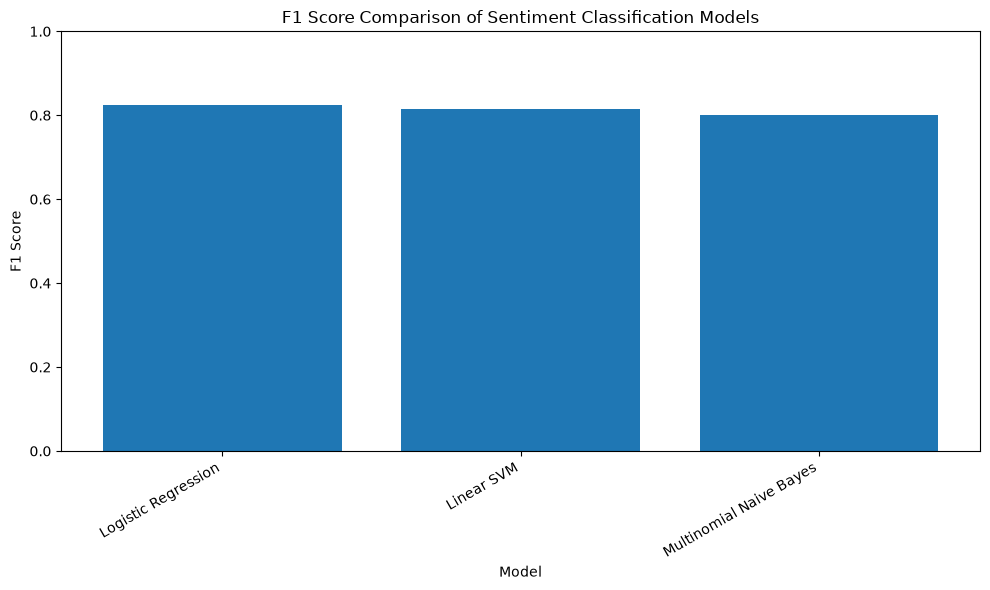

In [57]:
# 17. MODEL PERFORMANCE PLOT

print("\n" + "=" * 80)
print("[17] MODEL PERFORMANCE VISUALISATION")
print("=" * 80)


plt.figure(
    figsize=(10, 6)
)


plt.bar(

    test_results_df["Model"],

    test_results_df["F1"]
)


plt.ylabel(
    "F1 Score"
)


plt.xlabel(
    "Model"
)


plt.title(
    "F1 Score Comparison of Sentiment Classification Models"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.ylim(
    0,
    1
)


plt.tight_layout()


plt.show()

plt.figure(
    figsize=(10, 6)
)


plt.bar(

    test_results_df["Model"],

    test_results_df["F1"]
)


plt.ylabel(
    "F1 Score"
)


plt.xlabel(
    "Model"
)


plt.title(
    "F1 Score Comparison of Sentiment Classification Models"
)


plt.xticks(
    rotation=30,
    ha="right"
)


plt.ylim(
    0,
    1
)


plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "01_model_f1_comparison.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.close()



In [58]:
# 18. SELECT BEST MODEL

print("\n" + "=" * 80)
print("[18] SELECT BEST MODEL")
print("=" * 80)


best_model_name = (
    test_results_df
    .iloc[0]["Model"]
)


best_model = trained_models[
    best_model_name
]


best_predictions = test_predictions[
    best_model_name
]


best_probabilities = test_probabilities[
    best_model_name
]


print(
    f"Selected model: "
    f"{best_model_name}"
)


print(
    "\nClassification report:"
)


print(

    classification_report(

        y_test,

        best_predictions,

        target_names=[
            "Negative",
            "Positive"
        ],

        digits=4,

        zero_division=0
    )
)




[18] SELECT BEST MODEL
Selected model: Logistic Regression

Classification report:
              precision    recall  f1-score   support

    Negative     0.8288    0.8152    0.8220    159669
    Positive     0.8181    0.8316    0.8248    159613

    accuracy                         0.8234    319282
   macro avg     0.8235    0.8234    0.8234    319282
weighted avg     0.8235    0.8234    0.8234    319282




[19] CONFUSION MATRIX


,Predicted Negative,Predicted Positive
Actual Negative,130166,29503
Actual Positive,26886,132727


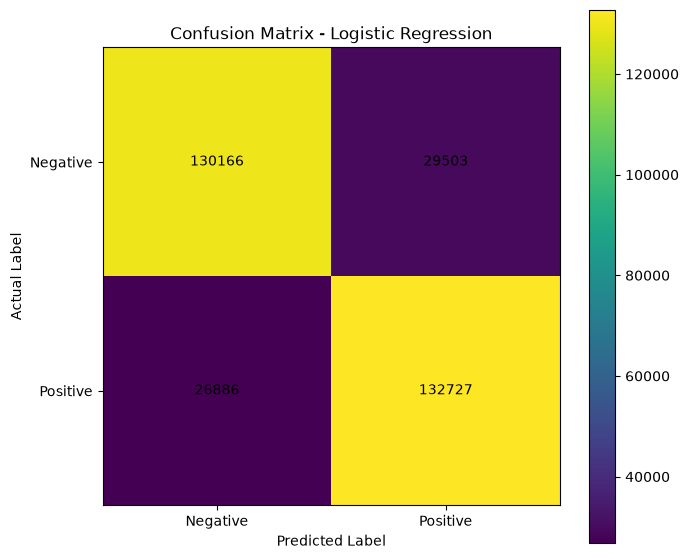

In [59]:
# 19. CONFUSION MATRIX

print("\n" + "=" * 80)
print("[19] CONFUSION MATRIX")
print("=" * 80)


cm = confusion_matrix(

    y_test,

    best_predictions
)


cm_df = pd.DataFrame(

    cm,

    index=[
        "Actual Negative",
        "Actual Positive"
    ],

    columns=[
        "Predicted Negative",
        "Predicted Positive"
    ]
)


display(cm_df)


cm_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "07_confusion_matrix.csv"
    )
)


plt.figure(
    figsize=(7, 6)
)


plt.imshow(cm)


plt.title(
    f"Confusion Matrix - {best_model_name}"
)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "Actual Label"
)


plt.xticks(
    [0, 1],
    [
        "Negative",
        "Positive"
    ]
)


plt.yticks(
    [0, 1],
    [
        "Negative",
        "Positive"
    ]
)


for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"
        )


plt.colorbar()


plt.tight_layout()


plt.show()


# Save

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "02_confusion_matrix.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.close()



In [60]:
# 20. CALIBRATION

print("\n" + "=" * 80)
print("[20] CONFIDENCE CALIBRATION")
print("=" * 80)

if best_model_name == "Linear SVM":

    print(
        "\nSelected model is Linear SVM."
    )

    print(
        "Applying sigmoid probability calibration."
    )


    calibration_base_model = LinearSVC(

        C=best_model.get_params()["C"],

        class_weight="balanced",

        random_state=RANDOM_STATE
    )


    calibrated_model = CalibratedClassifierCV(

        estimator=calibration_base_model,

        method="sigmoid",

        cv=CV_FOLDS,

        n_jobs=-1
    )


else:

    print(
        f"\nSelected model is "
        f"{best_model_name}."
    )

    print(
        "Applying sigmoid probability calibration."
    )


    calibrated_model = CalibratedClassifierCV(

        estimator=best_model,

        method="sigmoid",

        cv=CV_FOLDS,

        n_jobs=-1
    )


print(
    "\nFitting calibration model..."
)


calibrated_model.fit(

    X_train_tfidf,

    y_train
)


# ------------------------------------------------
# Proper calibrated probabilities
# ------------------------------------------------

calibrated_probabilities = (

    calibrated_model
    .predict_proba(
        X_test_tfidf
    )[:, 1]
)


# ------------------------------------------------
# Calibrated predictions
# ------------------------------------------------

calibrated_predictions = (

    calibrated_probabilities
    >= 0.5
).astype(int)


# ------------------------------------------------
# Calibrated confidence
# ------------------------------------------------

calibrated_confidence = np.maximum(

    calibrated_probabilities,

    1 -
    calibrated_probabilities
)


# ------------------------------------------------
# Metrics
# ------------------------------------------------

calibrated_accuracy = accuracy_score(

    y_test,

    calibrated_predictions
)


calibrated_precision = precision_score(

    y_test,

    calibrated_predictions,

    zero_division=0
)


calibrated_recall = recall_score(

    y_test,

    calibrated_predictions,

    zero_division=0
)


calibrated_f1 = f1_score(

    y_test,

    calibrated_predictions,

    zero_division=0
)


calibrated_roc_auc = roc_auc_score(

    y_test,

    calibrated_probabilities
)


calibrated_pr_auc = average_precision_score(

    y_test,

    calibrated_probabilities
)


calibrated_brier = brier_score_loss(

    y_test,

    calibrated_probabilities
)


print(
    "\nCalibrated model performance:"
)


print(
    f"Accuracy : {calibrated_accuracy:.4f}"
)


print(
    f"Precision: {calibrated_precision:.4f}"
)


print(
    f"Recall   : {calibrated_recall:.4f}"
)


print(
    f"F1       : {calibrated_f1:.4f}"
)


print(
    f"ROC-AUC  : {calibrated_roc_auc:.4f}"
)


print(
    f"PR-AUC   : {calibrated_pr_auc:.4f}"
)


print(
    f"Brier    : {calibrated_brier:.6f}"
)




[20] CONFIDENCE CALIBRATION

Selected model is Logistic Regression.
Applying sigmoid probability calibration.

Fitting calibration model...

Calibrated model performance:
Accuracy : 0.8224
Precision: 0.8179
Recall   : 0.8293
F1       : 0.8236
ROC-AUC  : 0.9015
PR-AUC   : 0.9022
Brier    : 0.126250


In [61]:
# 21. EXPECTED CALIBRATION ERROR

print("\n" + "=" * 80)
print("[21] EXPECTED CALIBRATION ERROR (ECE)")
print("=" * 80)


def calculate_ece(
    y_true,
    probabilities,
    n_bins=10
):

    """
    Calculates Expected Calibration Error.

    Lower ECE indicates better agreement between
    model confidence and observed accuracy.
    """


    y_true = np.asarray(
        y_true
    )


    probabilities = np.asarray(
        probabilities
    )


    confidence = np.maximum(

        probabilities,

        1 -
        probabilities
    )


    predictions = (

        probabilities
        >= 0.5
    ).astype(int)


    correctness = (

        predictions
        ==
        y_true
    ).astype(int)


    bin_edges = np.linspace(

        0,

        1,

        n_bins + 1
    )


    ece = 0.0


    rows = []


    for i in range(n_bins):

        lower = bin_edges[i]

        upper = bin_edges[i + 1]


        if i == n_bins - 1:

            mask = (

                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            mask = (

                (confidence >= lower)
                &
                (confidence < upper)
            )


        count = mask.sum()


        if count > 0:

            bin_accuracy = (
                correctness[mask]
                .mean()
            )


            bin_confidence = (
                confidence[mask]
                .mean()
            )


            bin_error = abs(

                bin_accuracy
                -
                bin_confidence
            )


            ece += (

                count
                /
                len(y_true)
            ) * bin_error


            rows.append({

                "Bin_Lower":
                    lower,

                "Bin_Upper":
                    upper,

                "Count":
                    count,

                "Mean_Confidence":
                    bin_confidence,

                "Accuracy":
                    bin_accuracy,

                "Absolute_Gap":
                    bin_error
            })


    return ece, pd.DataFrame(rows)


if best_model_name == "Linear SVM":

    uncalibrated_ece = np.nan

    uncalibrated_ece_table = pd.DataFrame()

    print(
        "Uncalibrated ECE: N/A"
    )

    print(
        "Reason: Linear SVM does not produce "
        "probabilities before calibration."
    )

else:

    uncalibrated_ece, uncalibrated_ece_table = (

        calculate_ece(

            y_test,

            best_probabilities
        )
    )


    print(
        f"Uncalibrated ECE: "
        f"{uncalibrated_ece:.6f}"
    )


# ------------------------------------------------
# Calibrated ECE
# ------------------------------------------------

calibrated_ece, calibrated_ece_table = (

    calculate_ece(

        y_test,

        calibrated_probabilities
    )
)


print(
    f"Calibrated ECE:   "
    f"{calibrated_ece:.6f}"
)


print(
    "\nLower ECE indicates better calibration."
)





[21] EXPECTED CALIBRATION ERROR (ECE)
Uncalibrated ECE: 0.017193
Calibrated ECE:   0.010625

Lower ECE indicates better calibration.



[22] RELIABILITY DIAGRAM


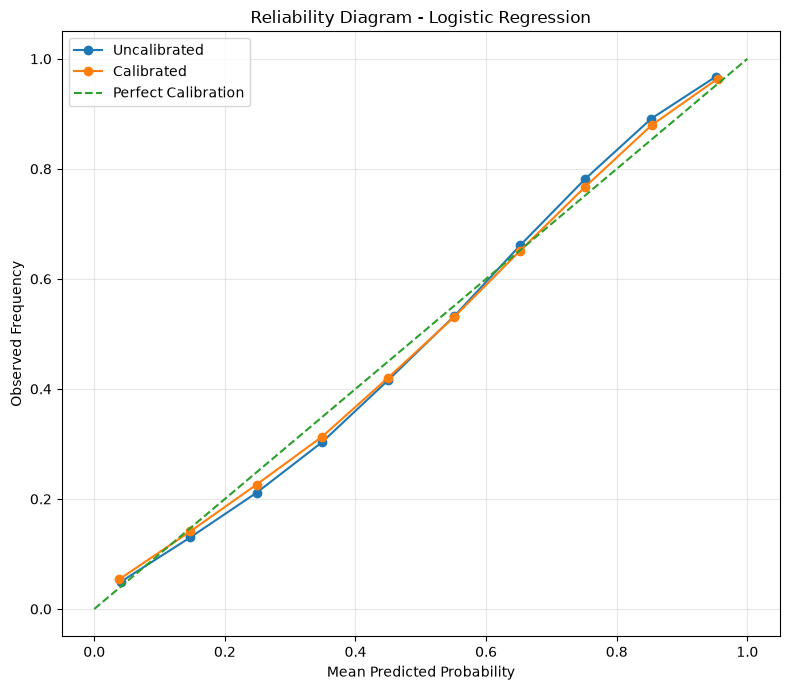

In [62]:
# 22. CALIBRATION CURVE / RELIABILITY DIAGRAM

print("\n" + "=" * 80)
print("[22] RELIABILITY DIAGRAM")
print("=" * 80)


prob_true_calibrated, prob_pred_calibrated = (

    calibration_curve(

        y_test,

        calibrated_probabilities,

        n_bins=10,

        strategy="uniform"
    )
)



if best_model_name != "Linear SVM":

    prob_true_uncalibrated, prob_pred_uncalibrated = (

        calibration_curve(

            y_test,

            best_probabilities,

            n_bins=10,

            strategy="uniform"
        )
    )

else:

    prob_true_uncalibrated = None

    prob_pred_uncalibrated = None


plt.figure(
    figsize=(8, 7)
)


if prob_true_uncalibrated is not None:

    plt.plot(

        prob_pred_uncalibrated,

        prob_true_uncalibrated,

        marker="o",

        label="Uncalibrated"
    )


plt.plot(

    prob_pred_calibrated,

    prob_true_calibrated,

    marker="o",

    label="Calibrated"
)


plt.plot(

    [0, 1],

    [0, 1],

    linestyle="--",

    label="Perfect Calibration"
)


plt.xlabel(
    "Mean Predicted Probability"
)


plt.ylabel(
    "Observed Frequency"
)


plt.title(

    f"Reliability Diagram - "
    f"{best_model_name}"
)


plt.legend()


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()





In [63]:
# 23. CALIBRATION RESULTS TABLE

print("\n" + "=" * 80)
print("[23] CALIBRATION RESULTS")
print("=" * 80)


uncalibrated_brier = (

    brier_score_loss(

        y_test,

        best_probabilities

    )
    if best_model_name != "Linear SVM"
    else np.nan
)


calibration_results = pd.DataFrame([

    {

        "Model":
            best_model_name,

        "Type":
            "Uncalibrated",

        "Brier_Score":
            uncalibrated_brier,

        "ECE":
            uncalibrated_ece
    },

    {

        "Model":
            best_model_name,

        "Type":
            "Calibrated",

        "Brier_Score":
            calibrated_brier,

        "ECE":
            calibrated_ece
    }

])


display(

    calibration_results.style.format({

        "Brier_Score":
            lambda x:
            "N/A"
            if pd.isna(x)
            else f"{x:.6f}",

        "ECE":
            lambda x:
            "N/A"
            if pd.isna(x)
            else f"{x:.6f}"
    })
)





[23] CALIBRATION RESULTS


,Model,Type,Brier_Score,ECE
0,Logistic Regression,Uncalibrated,0.125908,0.017193
1,Logistic Regression,Calibrated,0.126250,0.010625



[24] CONFIDENCE ANALYSIS

Confidence statistics:


,Confidence
count,319282.000000
mean,0.814758
std,0.146772
min,0.500000
25%,0.698661
50%,0.848952
75%,0.945914
max,1.000000


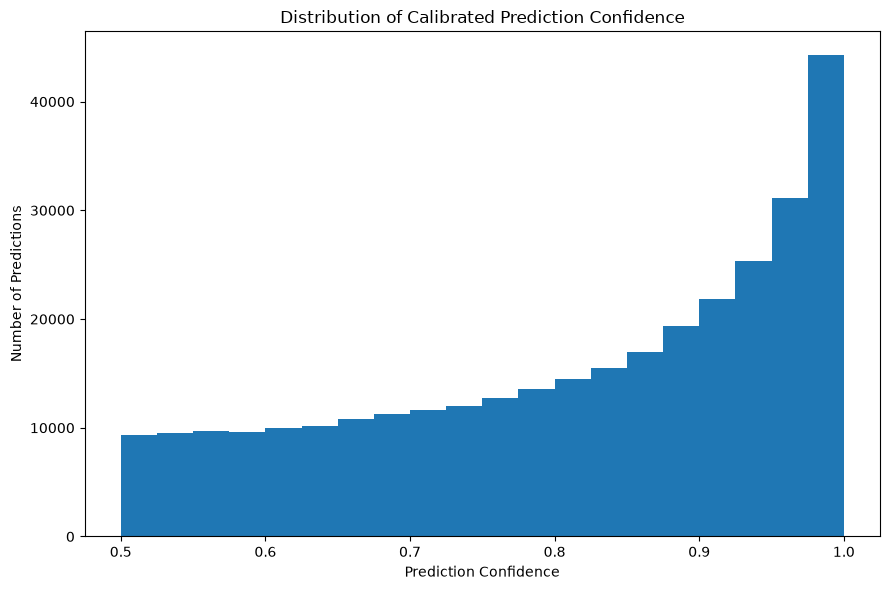

In [64]:
# 24. CONFIDENCE ANALYSIS

print("\n" + "=" * 80)
print("[24] CONFIDENCE ANALYSIS")
print("=" * 80)


confidence = calibrated_confidence


correct = (

    calibrated_predictions
    ==
    np.asarray(y_test)
)


confidence_analysis = pd.DataFrame({

    "Confidence":
        confidence,

    "Prediction":
        calibrated_predictions,

    "Actual":
        np.asarray(y_test),

    "Correct":
        correct
})


print(
    "\nConfidence statistics:"
)


display(

    confidence_analysis[
        "Confidence"
    ]
    .describe()
    .to_frame(
        "Confidence"
    )
)


# ------------------------------------------------
# Confidence histogram
# ------------------------------------------------

plt.figure(
    figsize=(9, 6)
)


plt.hist(

    confidence,

    bins=20
)


plt.xlabel(
    "Prediction Confidence"
)


plt.ylabel(
    "Number of Predictions"
)


plt.title(
    "Distribution of Calibrated Prediction Confidence"
)


plt.tight_layout()


plt.show()


# Save

plt.figure(
    figsize=(9, 6)
)


plt.hist(

    confidence,

    bins=20
)


plt.xlabel(
    "Prediction Confidence"
)


plt.ylabel(
    "Number of Predictions"
)


plt.title(
    "Distribution of Calibrated Prediction Confidence"
)


plt.tight_layout()



plt.close()


In [65]:
# 25. CONFIDENCE BIN ANALYSIS

print("\n" + "=" * 80)
print("[25] CONFIDENCE BIN ANALYSIS")
print("=" * 80)


confidence_bins = [

    0.50,

    0.60,

    0.70,

    0.80,

    0.90,

    0.95,

    1.00
]


confidence_labels = [

    "0.50-0.60",

    "0.60-0.70",

    "0.70-0.80",

    "0.80-0.90",

    "0.90-0.95",

    "0.95-1.00"
]


confidence_analysis[
    "Confidence_Bin"
] = pd.cut(

    confidence_analysis[
        "Confidence"
    ],

    bins=confidence_bins,

    labels=confidence_labels,

    include_lowest=True
)


confidence_bin_summary = (

    confidence_analysis

    .groupby(

        "Confidence_Bin",

        observed=False

    )

    .agg(

        Number_of_Predictions=(
            "Correct",
            "size"
        ),

        Accuracy=(
            "Correct",
            "mean"
        ),

        Mean_Confidence=(
            "Confidence",
            "mean"
        )

    )

    .reset_index()
)


confidence_bin_summary[
    "Error_Rate"
] = (

    1 -
    confidence_bin_summary[
        "Accuracy"
    ]
)


display(

    confidence_bin_summary.style.format({

        "Accuracy":
            "{:.4f}",

        "Mean_Confidence":
            "{:.4f}",

        "Error_Rate":
            "{:.4f}"
    })
)


confidence_bin_summary.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "11_confidence_bin_analysis.csv"
    ),

    index=False
)




[25] CONFIDENCE BIN ANALYSIS


,Confidence_Bin,Number_of_Predictions,Accuracy,Mean_Confidence,Error_Rate
0,0.50-0.60,38215,0.5548,0.5504,0.4452
1,0.60-0.70,42177,0.6680,0.6516,0.3320
2,0.70-0.80,49945,0.7706,0.7517,0.2294
3,0.80-0.90,66294,0.8700,0.8532,0.1300
4,0.90-0.95,47233,0.9278,0.9262,0.0722
5,0.95-1.00,75418,0.9707,0.9781,0.0293


In [66]:
# 26. SELECTIVE PREDICTION

print("\n" + "=" * 80)
print("[26] SELECTIVE PREDICTION / ACCEPT-REVIEW")
print("=" * 80)


def selective_prediction_analysis(

    y_true,

    predictions,

    probabilities,

    thresholds
):

    """
    Selective prediction:

    High-confidence predictions are ACCEPTED.

    Low-confidence predictions are sent
    for HUMAN REVIEW.

    Coverage:
        proportion of predictions accepted.

    Review rate:
        proportion sent for review.

    Selective risk:
        error rate among accepted predictions.
    """


    confidence = np.maximum(

        probabilities,

        1 -
        probabilities
    )


    results = []


    for threshold in thresholds:

        accepted = (

            confidence
            >= threshold
        )


        reviewed = ~accepted


        accepted_count = (
            accepted.sum()
        )


        reviewed_count = (
            reviewed.sum()
        )


        coverage = (

            accepted_count
            /
            len(y_true)
        )


        review_rate = (

            reviewed_count
            /
            len(y_true)
        )


        if accepted_count > 0:

            accepted_accuracy = (

                accuracy_score(

                    np.asarray(
                        y_true
                    )[accepted],

                    np.asarray(
                        predictions
                    )[accepted]
                )
            )


            selective_risk = (

                1 -
                accepted_accuracy
            )

        else:

            accepted_accuracy = np.nan

            selective_risk = np.nan


        results.append({

            "Threshold":
                threshold,

            "Accepted":
                accepted_count,

            "Reviewed":
                reviewed_count,

            "Coverage":
                coverage,

            "Review_Rate":
                review_rate,

            "Accepted_Accuracy":
                accepted_accuracy,

            "Selective_Risk":
                selective_risk
        })


    return pd.DataFrame(
        results
    )


thresholds = [

    0.60,

    0.70,

    0.80,

    0.90,

    0.95
]


selective_results = (

    selective_prediction_analysis(

        y_test,

        calibrated_predictions,

        calibrated_probabilities,

        thresholds
    )
)


display(

    selective_results.style.format({

        "Coverage":
            "{:.4f}",

        "Review_Rate":
            "{:.4f}",

        "Accepted_Accuracy":
            "{:.4f}",

        "Selective_Risk":
            "{:.4f}"
    })
)


selective_results.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "12_selective_prediction_results.csv"
    ),

    index=False
)




[26] SELECTIVE PREDICTION / ACCEPT-REVIEW


,Threshold,Accepted,Reviewed,Coverage,Review_Rate,Accepted_Accuracy,Selective_Risk
0,0.600000,281067,38215,0.8803,0.1197,0.8588,0.1412
1,0.700000,238890,80392,0.7482,0.2518,0.8924,0.1076
2,0.800000,188945,130337,0.5918,0.4082,0.9247,0.0753
3,0.900000,122651,196631,0.3841,0.6159,0.9542,0.0458
4,0.950000,75418,243864,0.2362,0.7638,0.9707,0.0293



[27] RISK-COVERAGE CURVE


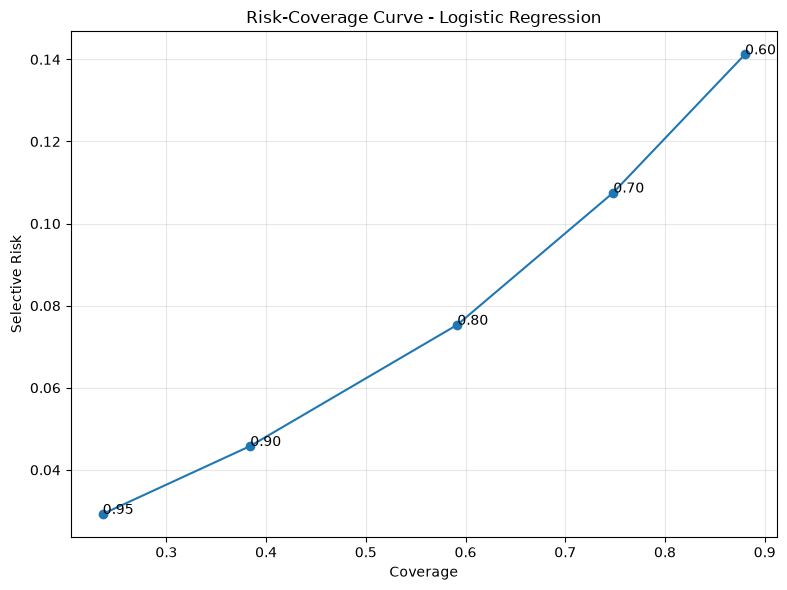

In [67]:
# 27. RISK-COVERAGE CURVE

print("\n" + "=" * 80)
print("[27] RISK-COVERAGE CURVE")
print("=" * 80)


plt.figure(
    figsize=(8, 6)
)


plt.plot(

    selective_results[
        "Coverage"
    ],

    selective_results[
        "Selective_Risk"
    ],

    marker="o"
)


for _, row in selective_results.iterrows():

    plt.annotate(

        f"{row['Threshold']:.2f}",

        (

            row["Coverage"],

            row["Selective_Risk"]
        )
    )


plt.xlabel(
    "Coverage"
)


plt.ylabel(
    "Selective Risk"
)


plt.title(

    f"Risk-Coverage Curve - "
    f"{best_model_name}"
)


plt.grid(
    True,
    alpha=0.3
)


plt.tight_layout()


plt.show()


# Save

plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "05_risk_coverage_curve.png"
    ),

    dpi=300,

    bbox_inches="tight"
)


plt.close()



In [68]:
# 28. ACCEPT / REVIEW DECISION

print("\n" + "=" * 80)
print("[28] ACCEPT / REVIEW DECISIONS")
print("=" * 80)


accept_review_summary = []


for threshold in thresholds:

    accepted = (

        calibrated_confidence
        >= threshold
    )


    reviewed = ~accepted


    accepted_count = (
        accepted.sum()
    )


    reviewed_count = (
        reviewed.sum()
    )


    accepted_percentage = (

        accepted.mean()
        *
        100
    )


    review_percentage = (

        reviewed.mean()
        *
        100
    )


    accepted_accuracy = (

        correct[accepted].mean()

        if accepted_count > 0

        else np.nan
    )


    accept_review_summary.append({

        "Threshold":
            threshold,

        "Accepted_Count":
            accepted_count,

        "Review_Count":
            reviewed_count,

        "Accepted_Percentage":
            accepted_percentage,

        "Review_Percentage":
            review_percentage,

        "Accepted_Accuracy":
            accepted_accuracy
    })


accept_review_df = pd.DataFrame(

    accept_review_summary
)


display(

    accept_review_df.style.format({

        "Accepted_Percentage":
            "{:.2f}",

        "Review_Percentage":
            "{:.2f}",

        "Accepted_Accuracy":
            "{:.4f}"
    })
)


accept_review_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "13_accept_review_summary.csv"
    ),

    index=False
)




[28] ACCEPT / REVIEW DECISIONS


,Threshold,Accepted_Count,Review_Count,Accepted_Percentage,Review_Percentage,Accepted_Accuracy
0,0.600000,281067,38215,88.03,11.97,0.8588
1,0.700000,238890,80392,74.82,25.18,0.8924
2,0.800000,188945,130337,59.18,40.82,0.9247
3,0.900000,122651,196631,38.41,61.59,0.9542
4,0.950000,75418,243864,23.62,76.38,0.9707


In [69]:
# 29. HIGH-CONFIDENCE ERROR ANALYSIS

print("\n" + "=" * 80)
print("[29] HIGH-CONFIDENCE ERROR ANALYSIS")
print("=" * 80)


HIGH_CONFIDENCE_THRESHOLD = 0.90


high_confidence_error_mask = (

    (
        calibrated_confidence
        >= HIGH_CONFIDENCE_THRESHOLD
    )

    &

    (
        ~correct
    )
)


# ------------------------------------------------
# Build error dataframe
# ------------------------------------------------

high_confidence_errors = pd.DataFrame({

    "Original_Text":
        X_test.values,

    "Actual":
        np.asarray(y_test),

    "Predicted":
        calibrated_predictions,

    "Probability_Positive":
        calibrated_probabilities,

    "Confidence":
        calibrated_confidence,

    "Correct":
        correct
})


high_confidence_errors = (

    high_confidence_errors[
        high_confidence_error_mask
    ]
    .copy()
)


# ------------------------------------------------
# Labels
# ------------------------------------------------

high_confidence_errors[
    "Actual_Label"
] = (

    high_confidence_errors[
        "Actual"
    ]
    .map({

        0:
            "Negative",

        1:
            "Positive"
    })
)


high_confidence_errors[
    "Predicted_Label"
] = (

    high_confidence_errors[
        "Predicted"
    ]
    .map({

        0:
            "Negative",

        1:
            "Positive"
    })
)


# ------------------------------------------------
# Manual error categories
# ------------------------------------------------

error_categories = [

    "Sarcasm",

    "Irony",

    "Negation",

    "Slang",

    "Ambiguity",

    "Mixed sentiment",

    "Context dependence",

    "Other"
]


high_confidence_errors[
    "Error_Category"
] = "Uncoded"


print(

    f"High-confidence errors "
    f"(confidence >= "
    f"{HIGH_CONFIDENCE_THRESHOLD:.2f}): "
    f"{len(high_confidence_errors):,}"
)


display(

    high_confidence_errors.head(20)
)



print(
    "\nAvailable manual coding categories:"
)


for category in error_categories:

    print(
        "•",
        category
    )




[29] HIGH-CONFIDENCE ERROR ANALYSIS
High-confidence errors (confidence >= 0.90): 5,619


,Original_Text,Actual,Predicted,Probability_Positive,Confidence,Correct,Actual_Label,Predicted_Label,Error_Category
25,me too i like listening to rain when i dont ha...,1,0,0.049715,0.950285,False,Positive,Negative,Uncoded
101,hard to go walkies with no paws,1,0,0.076418,0.923582,False,Positive,Negative,Uncoded
132,i can talk i mean i wish i was at ripe,1,0,0.014120,0.985880,False,Positive,Negative,Uncoded
287,jst finished bathing the kid and enjoying the ...,0,1,0.928279,0.928279,False,Negative,Positive,Uncoded
303,hey u i likeddiddid that movi whre u been tho ...,1,0,0.080053,0.919947,False,Positive,Negative,Uncoded
329,lari just told me quot i'm sick like mommy my ...,1,0,0.037703,0.962297,False,Positive,Negative,Uncoded
400,my lake is brocken ohhhh noooo i hate radball,1,0,0.006506,0.993494,False,Positive,Negative,Uncoded
496,yeah i watched the game haha felt really sleep...,1,0,0.082085,0.917915,False,Positive,Negative,Uncoded
549,i haven't stepped out of my house in the last ...,1,0,0.080965,0.919035,False,Positive,Negative,Uncoded
627,watching countdown i got 'ski',0,1,0.931997,0.931997,False,Negative,Positive,Uncoded



Available manual coding categories:
• Sarcasm
• Irony
• Negation
• Slang
• Ambiguity
• Mixed sentiment
• Context dependence
• Other


In [70]:
# 30. HIGH-CONFIDENCE ERROR RATE

print("\n" + "=" * 80)
print("[30] HIGH-CONFIDENCE ERROR RATE")
print("=" * 80)


total_predictions = len(y_test)


high_confidence_error_count = (

    high_confidence_error_mask.sum()
)


high_confidence_error_rate = (

    high_confidence_error_count
    /
    total_predictions
)


accepted_high_confidence_count = (

    (
        calibrated_confidence
        >= HIGH_CONFIDENCE_THRESHOLD
    )
    .sum()
)


accepted_high_confidence_accuracy = (

    correct[
        calibrated_confidence
        >= HIGH_CONFIDENCE_THRESHOLD
    ].mean()

    if accepted_high_confidence_count > 0

    else np.nan
)


high_confidence_summary = pd.DataFrame([{

    "Threshold":
        HIGH_CONFIDENCE_THRESHOLD,

    "High_Confidence_Predictions":
        accepted_high_confidence_count,

    "High_Confidence_Errors":
        high_confidence_error_count,

    "High_Confidence_Error_Rate":
        high_confidence_error_rate,

    "Accepted_High_Confidence_Accuracy":
        accepted_high_confidence_accuracy

}])


display(

    high_confidence_summary.style.format({

        "High_Confidence_Error_Rate":
            "{:.6f}",

        "Accepted_High_Confidence_Accuracy":
            "{:.6f}"
    })
)




[30] HIGH-CONFIDENCE ERROR RATE


,Threshold,High_Confidence_Predictions,High_Confidence_Errors,High_Confidence_Error_Rate,Accepted_High_Confidence_Accuracy
0,0.900000,122651,5619,0.017599,0.954187


In [71]:
print("\n" + "=" * 80)
print("FINAL MODEL PERFORMANCE")
print("=" * 80)

print(f"Best Model              : {best_model_name}")
print(f"Accuracy                : {test_results_df.iloc[0]['Accuracy']:.4f}")
print(f"F1 Score                : {test_results_df.iloc[0]['F1']:.4f}")
print(f"ROC-AUC                 : {test_results_df.iloc[0]['ROC_AUC']:.4f}")
print(f"PR-AUC                  : {test_results_df.iloc[0]['PR_AUC']:.4f}")

print("\n" + "=" * 80)
print("CALIBRATION RESULTS")
print("=" * 80)

print(f"Calibrated Accuracy     : {calibrated_accuracy:.4f}")
print(f"Calibrated F1           : {calibrated_f1:.4f}")
print(f"Calibrated Brier Score  : {calibrated_brier:.6f}")
print(f"Calibrated ECE          : {calibrated_ece:.6f}")

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE RESULTS")
print("=" * 80)

print(f"Threshold               : {HIGH_CONFIDENCE_THRESHOLD}")
print(f"Errors                  : {high_confidence_error_count}")
print(f"Error Rate              : {high_confidence_error_rate:.6f}")

print("\n" + "=" * 80)
print("SELECTIVE PREDICTION")
print("=" * 80)

for model_name in all_model_selective_df["Model"].unique():

    temp = all_model_selective_df[
        all_model_selective_df["Model"] == model_name
    ]

    best = temp.loc[
        temp["Accepted_Accuracy"].idxmax()
    ]

    print(
        f"{model_name}: "
        f"Threshold={best['Threshold']:.2f}, "
        f"Coverage={best['Coverage']:.4f}, "
        f"Review Rate={best['Review_Rate']:.4f}, "
        f"Accuracy={best['Accepted_Accuracy']:.4f}, "
        f"Risk={best['Selective_Risk']:.4f}"
    )


FINAL MODEL PERFORMANCE
Best Model              : Logistic Regression
Accuracy                : 0.8234
F1 Score                : 0.8248
ROC-AUC                 : 0.9024
PR-AUC                  : 0.9031

CALIBRATION RESULTS
Calibrated Accuracy     : 0.8224
Calibrated F1           : 0.8236
Calibrated Brier Score  : 0.126250
Calibrated ECE          : 0.010625

HIGH-CONFIDENCE RESULTS
Threshold               : 0.9
Errors                  : 5619
Error Rate              : 0.017599

SELECTIVE PREDICTION
Logistic Regression: Threshold=0.95, Coverage=0.2055, Review Rate=0.7945, Accuracy=0.9737, Risk=0.0263
Multinomial Naive Bayes: Threshold=0.95, Coverage=0.0804, Review Rate=0.9196, Accuracy=0.9858, Risk=0.0142
Linear SVM: Threshold=0.95, Coverage=0.1845, Review Rate=0.8155, Accuracy=0.9722, Risk=0.0278
